<a href="https://colab.research.google.com/github/useroo5/MachineLearning/blob/main/Supervised%2BUnsupervised_Learning/Cafe_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

" Аналіз відвідувачів кафе "

Опис проєкту: Цей проєкт досліджує взаємозв’язок між кількістю відвідувачів кафе та доходом, а також дозволяє сегментувати відвідувачів за їхньою поведінкою (частота візитів і середня сума замовлення).

1. Лінійна регресія: Прогноз доходу кафе

Лінійна регресія допомагає передбачити дохід кафе, якщо є дані про кількість відвідувачів.

Мета: Прогнозувати дохід кафе залежно від кількості відвідувачів.

Дані:

- Visitors (Кількість відвідувачів на день).
- Revenue (Дохід у гривнях).
Результат: Модель передбачає, як змінюється дохід кафе залежно від кількості відвідувачів.

2. Кластеризація: Сегментація відвідувачів
Кластеризація дозволяє зрозуміти, які типи клієнтів відвідують кафе (регулярні відвідувачі, випадкові тощо).
Мета: Розподілити відвідувачів кафе на групи за їхньою поведінкою:

- Frequency (Частота візитів).
- Average Spend (Середній чек).

Результат: Відвідувачі згруповані в 3 категорії, наприклад:

- Регулярні клієнти з високим чеком.
- Рідкі клієнти з середнім чеком.
- Випадкові клієнти з низьким чеком.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# Анализ прибыли за февраль

#Лінійна регресія: Прогноз доходу кафе

# 1 - Генерация данных

In [ ]:
np.random.seed(42)

visitors = np.random.randint(20, 30, 31)
revenue = visitors * 100 + np.random.randint(1, 100, 31)  - np.random.randint(1, 100, 31)
# кол-во дохода: +- 100 гривен от каждого посетителя +
# случайная прибыль/ убыток от одного до ста



print(visitors)
print(revenue)

[ 8 21 16 12  9 22  8 27 20 24 12 12 25 22  5  9 25  4 23 22  3 25 13  7
  3 29 22  2 13 27 23]
[ 805 2057 1631 1188  898 2284  813 2745 1937 2381 1226 1197 2558 2249
  549  910 2499  397 2214 2158  355 2449 1274  670  315 2898 2200  114
 1342 2738 2230]


In [ ]:
data = {
    "visitors": visitors,
    "revenue": revenue,
}

df = pd.DataFrame(data)
df.head(10)

,visitors,revenue
0,8,805
1,21,2057
2,16,1631
3,12,1188
4,9,898
5,22,2284
6,8,813
7,27,2745
8,20,1937
9,24,2381


# 2 - Раздел данных на тренировочные и тестировочные

In [ ]:
X = df[["visitors"]]
y = df["revenue"]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    train_size = 0.8,
                                                    random_state=42
                                                    )
print(len(X_train), len(X_test), len(y_train), len(y_test))

24 7 24 7


# 3 - Анализ данных и предсказание дохода

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

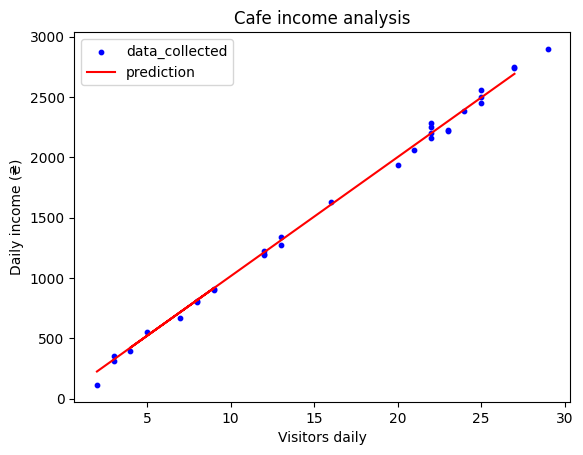

In [ ]:
plt.scatter(X, y, s = 10, color="blue", label = "data_collected")
plt.plot(X_test, y_pred, color = "red", label ="prediction")


plt.title("Cafe income analysis")
plt.xlabel("Visitors daily")
plt.ylabel("Daily income (₴)")
plt.legend()
plt.show()

# Кластеризация посетителей кафе

# 1 - Генерация данных

In [ ]:
np.random.seed(42)
frequency = np.random.randint(1, 50, 10)
average_money_spent = frequency * 10 - np.random.randint(1, 25, 10)

print(frequency)
print(average_money_spent)

[39 29 15 43  8 21 39 19 23 11]
[379 266 129 426  72 186 387 168 209 108]


In [ ]:
frequency_data = {
    "frequency(visits per month)":frequency,
    "average_money_spent":average_money_spent,
}
frequency_df = pd.DataFrame(frequency_data)
print(frequency_df)

   frequency(visits per month)  average_money_spent
0                           39                  379
1                           29                  266
2                           15                  129
3                           43                  426
4                            8                   72
5                           21                  186
6                           39                  387
7                           19                  168
8                           23                  209
9                           11                  108


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
frequency_df["cluster"] = kmeans.fit_predict(frequency_df[["frequency(visits per month)", "average_money_spent"]])
print(frequency_df)

   frequency(visits per month)  average_money_spent  cluster
0                           39                  379        0
1                           29                  266        2
2                           15                  129        1
3                           43                  426        0
4                            8                   72        1
5                           21                  186        2
6                           39                  387        0
7                           19                  168        1
8                           23                  209        2
9                           11                  108        1


In [ ]:
labels=kmeans.labels_
centroids = kmeans.cluster_centers_

print(labels, centroids)

[0 2 1 0 1 2 0 1 2 1] [[ 40.33333333 397.33333333]
 [ 13.25       119.25      ]
 [ 24.33333333 220.33333333]]


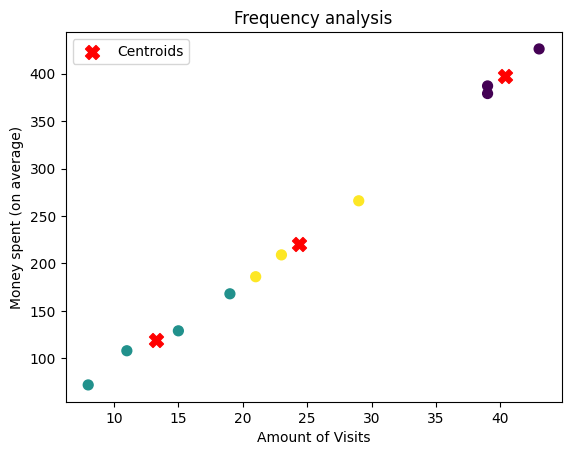

In [ ]:
plt.scatter(frequency_df["frequency(visits per month)"],
            frequency_df["average_money_spent"],
            s= 50,
            c= labels,
            cmap= "viridis")

plt.scatter(centroids[:,0],
            centroids[:,1],
            c="red",
            marker = "X",
            s = 100,
            label = "Centroids")

plt.title("Frequency analysis")
plt.xlabel("Amount of Visits")
plt.ylabel("Money spent (on average)")
plt.legend()
plt.show()

#Вывод:

**Линейная регрессия** показала, что доход кафе напрямую зависит от **количества посетителей**, что позволяет прогнозировать **выручку**.

**Кластеризация** разделила клиентов на три группы по **частоте визитов** и **среднему чеку**: регулярные с **высоким** чеком, редкие со **средним** и случайные с **низким**.

Результаты помогают лучше понять поведение клиентов и использовать это для планирования доходов и маркетинга.